In [1]:
import vitaldb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import resample_poly
from tqdm import tqdm

In [2]:
ppg_candidates = set(
    vitaldb.find_cases(['PLETH'])
)

art_candidates = set(
    vitaldb.find_cases(['ART'])
)

candidates = sorted(
    ppg_candidates.intersection(art_candidates)
)

print("Initial candidates:", len(candidates))


/tmp/ipykernel_2475668/4108409714.py:2: DeprecationWarning: find_cases() relies on the per-track 'trks' index, which is deprecated and may be removed in a future release.
  vitaldb.find_cases(['PLETH'])


Initial candidates: 3459


/tmp/ipykernel_2475668/4108409714.py:6: DeprecationWarning: find_cases() relies on the per-track 'trks' index, which is deprecated and may be removed in a future release.
  vitaldb.find_cases(['ART'])


In [4]:
# -----------------------------------------
# Exact waveform validation
# -----------------------------------------

common_cases = []
invalid_cases = []

for case_id in tqdm(candidates):

    try:

        vf = vitaldb.VitalFile(case_id)

        tracks = vf.trks

        # Exact tracks required
        if "SNUADC/PLETH" not in tracks:
            invalid_cases.append(
                (case_id, "missing_PPG")
            )
            continue

        if "SNUADC/ART" not in tracks:
            invalid_cases.append(
                (case_id, "missing_ART")
            )
            continue

        # Get tracks
        ppg_track = tracks["SNUADC/PLETH"]
        art_track = tracks["SNUADC/ART"]

        # -----------------------------------------
        # Check records
        # -----------------------------------------

        if len(ppg_track.recs) == 0:
            invalid_cases.append(
                (case_id, "PPG_no_records")
            )
            continue

        if len(art_track.recs) == 0:
            invalid_cases.append(
                (case_id, "ART_no_records")
            )
            continue

        # -----------------------------------------
        # Check first record has samples
        # -----------------------------------------

        ppg = np.asarray(
            ppg_track.recs[0]["val"]
        )

        art = np.asarray(
            art_track.recs[0]["val"]
        )

        if ppg.size == 0:
            invalid_cases.append(
                (case_id, "PPG_empty")
            )
            continue

        if art.size == 0:
            invalid_cases.append(
                (case_id, "ART_empty")
            )
            continue

        # -----------------------------------------
        # Check sampling rate
        # -----------------------------------------

        if float(ppg_track.srate) <= 0:
            invalid_cases.append(
                (case_id, "invalid_PPG_fs")
            )
            continue

        if float(art_track.srate) <= 0:
            invalid_cases.append(
                (case_id, "invalid_ART_fs")
            )
            continue

        # -----------------------------------------
        # Case passes
        # -----------------------------------------

        common_cases.append(case_id)

    except Exception as e:

        invalid_cases.append(
            (case_id, f"load_error: {e}")
        )


print("\n================================")
print("FINAL RESULT")
print("================================")

print(
    "Broad candidates:",
    len(candidates)
)

print(
    "Valid common cases:",
    len(common_cases)
)

print(
    "Rejected:",
    len(invalid_cases)
)

100%|██████████| 3459/3459 [2:30:31<00:00,  2.61s/it]     


FINAL RESULT
Broad candidates: 3459
Valid common cases: 3238
Rejected: 221


In [17]:
import pandas as pd

# -----------------------------------------
# Create validation DataFrame
# -----------------------------------------

valid_df = pd.DataFrame({
    "case_id": common_cases,
    "status": "valid"
})

invalid_df = pd.DataFrame(
    invalid_cases,
    columns=["case_id", "reason"]
)

invalid_df["status"] = "invalid"

# Combine
validation_df = pd.concat(
    [valid_df, invalid_df],
    ignore_index=True
)

# -----------------------------------------
# Save
# -----------------------------------------

validation_df.to_csv(
    "waveform_validation_results.csv",
    index=False
)

print("Saved:", len(validation_df), "cases")
print(validation_df.head())

Saved: 3238 cases
  case_id status reason
0       1  valid    NaN
1       4  valid    NaN
2       7  valid    NaN
3      10  valid    NaN
4      13  valid    NaN


In [5]:
from collections import Counter

reasons = Counter(
    reason for _, reason in invalid_cases
)

for reason, count in reasons.most_common():
    print(f"{reason}: {count}")

missing_ART: 204
missing_PPG: 10
load_error: <urlopen error [Errno -2] Name or service not known>: 4
load_error: Remote end closed connection without response: 1
PPG_no_records: 1
load_error: <urlopen error [Errno 104] Connection reset by peer>: 1


In [6]:
case_id = 1
vf = vitaldb.VitalFile(case_id)
data = vf.to_numpy(
    [
        "SNUADC/PLETH",
        "SNUADC/ART"
    ],
    interval=1/500
)

ppg = data[:, 0]
art = data[:, 1]

print("Data shape:", data.shape)
print("PPG shape:", ppg.shape)
print("ART shape:", art.shape)

Data shape: (5771049, 2)
PPG shape: (5771049,)
ART shape: (5771049,)


In [7]:
vf = vitaldb.VitalFile(case_id)

art_track = vf.trks["SNUADC/ART"]

print("Number of records:", len(art_track.recs))

for i, rec in enumerate(art_track.recs):

    values = np.asarray(rec["val"])

    print(
        f"Record {i}:",
        "shape =", values.shape,
        "size =", values.size,
        "NaNs =", np.isnan(values).sum() if values.size else 0
    )

Number of records: 1
Record 0: shape = (5770154,) size = 5770154 NaNs = 0


In [8]:
vf = vitaldb.VitalFile(1)

tracks = vf.get_track_names()

for track in tracks:
    if 'PLETH' in track.upper() or 'ART' in track.upper():
        print(track)

Solar8000/ART_MBP
Solar8000/ART_SBP
Solar8000/ART_DBP
Solar8000/PLETH_SPO2
Solar8000/PLETH_HR
SNUADC/ART
SNUADC/PLETH


In [9]:
ppg_track = vf.trks["SNUADC/PLETH"]
art_track = vf.trks["SNUADC/ART"]

print("PPG sampling rate:", ppg_track.srate)
print("ART sampling rate:", art_track.srate)

PPG sampling rate: 500.0
ART sampling rate: 500.0


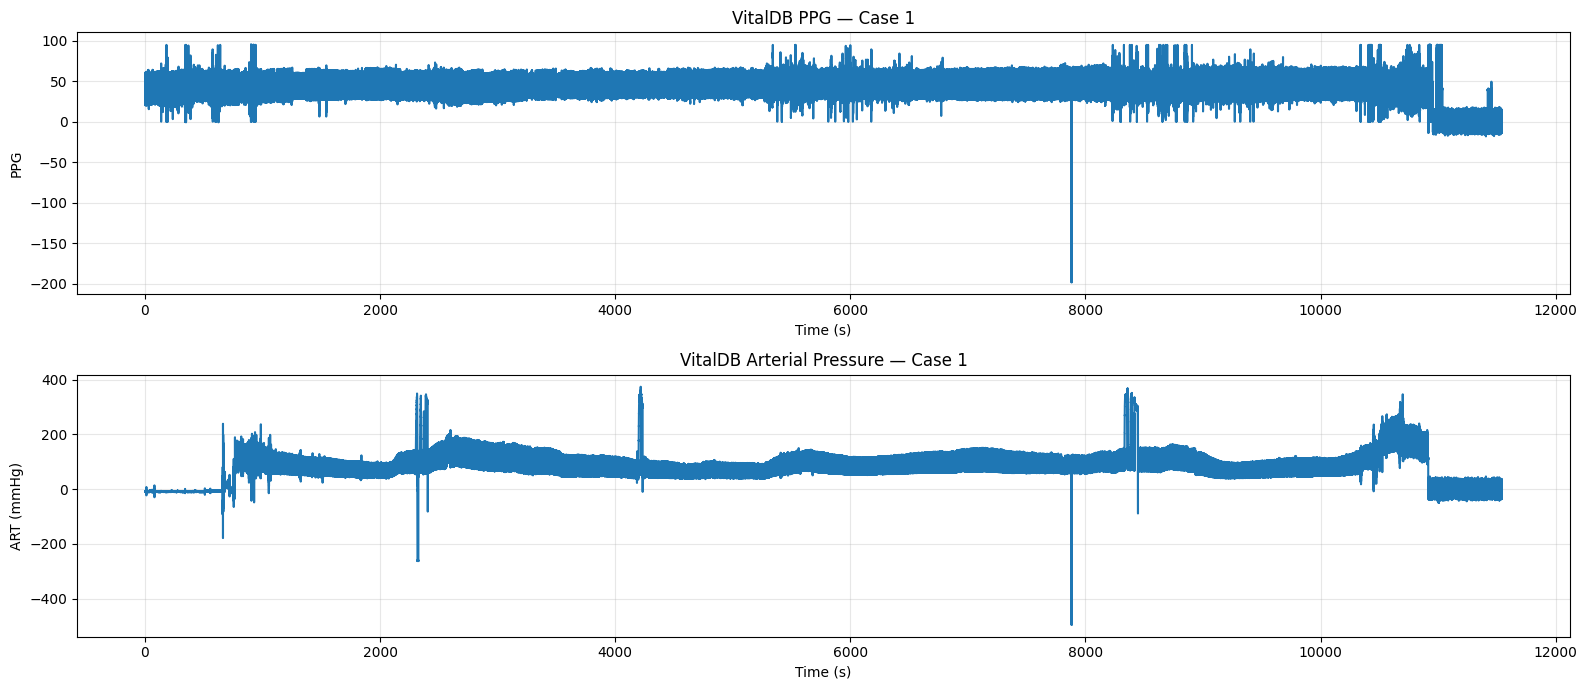

In [10]:
fs = 500

N = len(ppg)

time = np.arange(N) / fs

plt.figure(figsize=(16, 7))

plt.subplot(2, 1, 1)

plt.plot(
    time,
    ppg
)

plt.xlabel("Time (s)")
plt.ylabel("PPG")
plt.title(f"VitalDB PPG — Case {case_id}")
plt.grid(alpha=0.3)


plt.subplot(2, 1, 2)

plt.plot(
    time,
    art
)

plt.xlabel("Time (s)")
plt.ylabel("ART (mmHg)")
plt.title(f"VitalDB Arterial Pressure — Case {case_id}")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

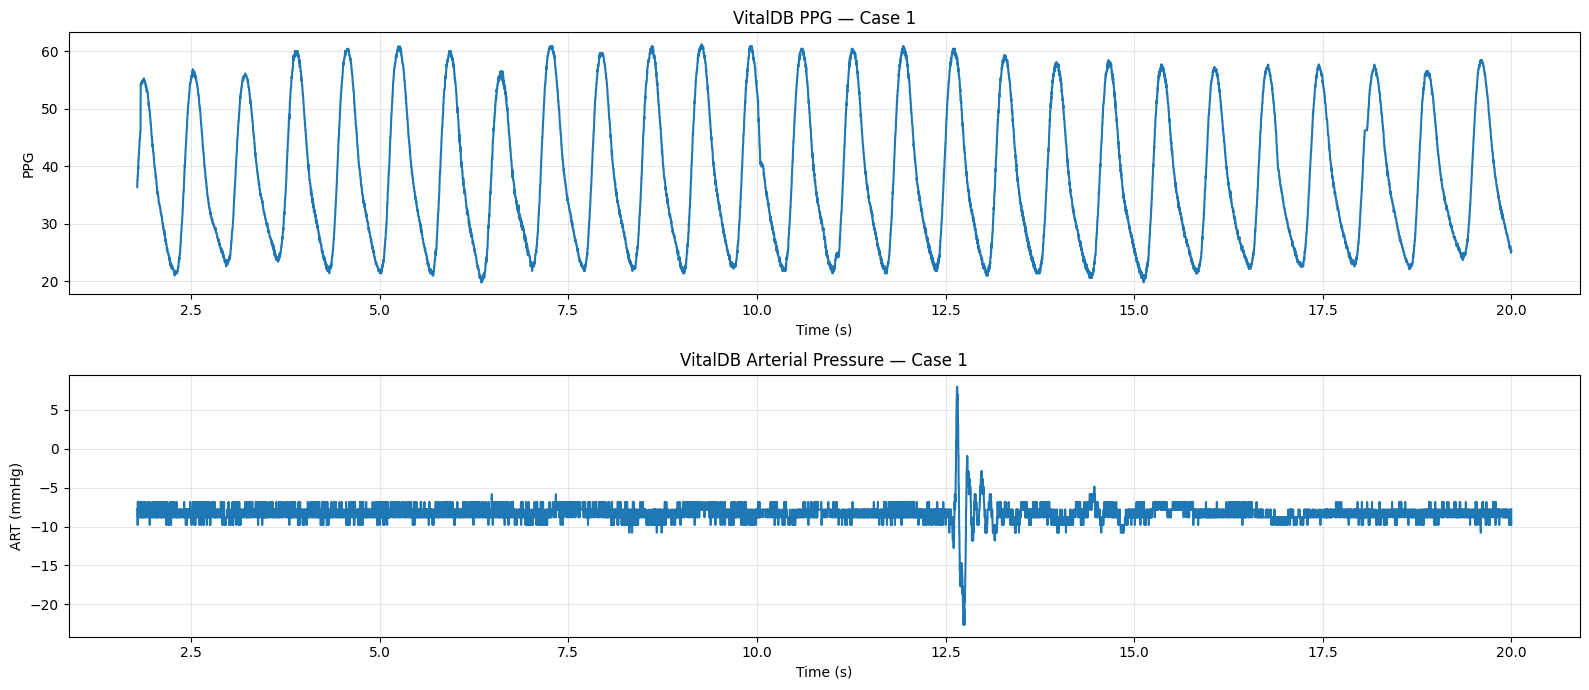

In [11]:
fs = 500
duration = 20

N = int(fs * duration)

time = np.arange(N) / fs

plt.figure(figsize=(16, 7))

plt.subplot(2, 1, 1)

plt.plot(
    time,
    ppg[:N]
)

plt.xlabel("Time (s)")
plt.ylabel("PPG")
plt.title(f"VitalDB PPG — Case {case_id}")
plt.grid(alpha=0.3)


plt.subplot(2, 1, 2)

plt.plot(
    time,
    art[:N]
)

plt.xlabel("Time (s)")
plt.ylabel("ART (mmHg)")
plt.title(f"VitalDB Arterial Pressure — Case {case_id}")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
print("PPG:")
print("min =", np.nanmin(ppg))
print("max =", np.nanmax(ppg))
print("mean =", np.nanmean(ppg))
print("std =", np.nanstd(ppg))

print("\nABP:")
print("min =", np.nanmin(art))
print("max =", np.nanmax(art))
print("mean =", np.nanmean(art))
print("std =", np.nanstd(art))

PPG:
min = -198.2504
max = 95.61682
mean = 37.815395
std = 15.085817

ABP:
min = -495.626
max = 374.32364
mean = 78.152565
std = 52.155697


## Downsampling ##

Vital DB dataset is sampled at 500Hz but UCI is at 125Hz. For zero-shot learning we thus need to downsample vital db dataset

In [13]:
def downsample_signal(signal, original_fs=500, target_fs=125):
    signal = np.asarray(signal, dtype=np.float32)

    # 500 Hz → 125 Hz = downsample by 4
    downsampled = resample_poly(
        signal,
        up=1,
        down=4
    )

    return downsampled.astype(np.float32)

In [14]:
ppg_500 = ppg  # 8 sec at 500 Hz
art_500 = art

ppg_125 = downsample_signal(
    ppg_500
)

print("Original shape:", ppg_500.shape)
print("Downsampled shape:", ppg_125.shape)


Original shape: (5771049,)
Downsampled shape: (1442763,)


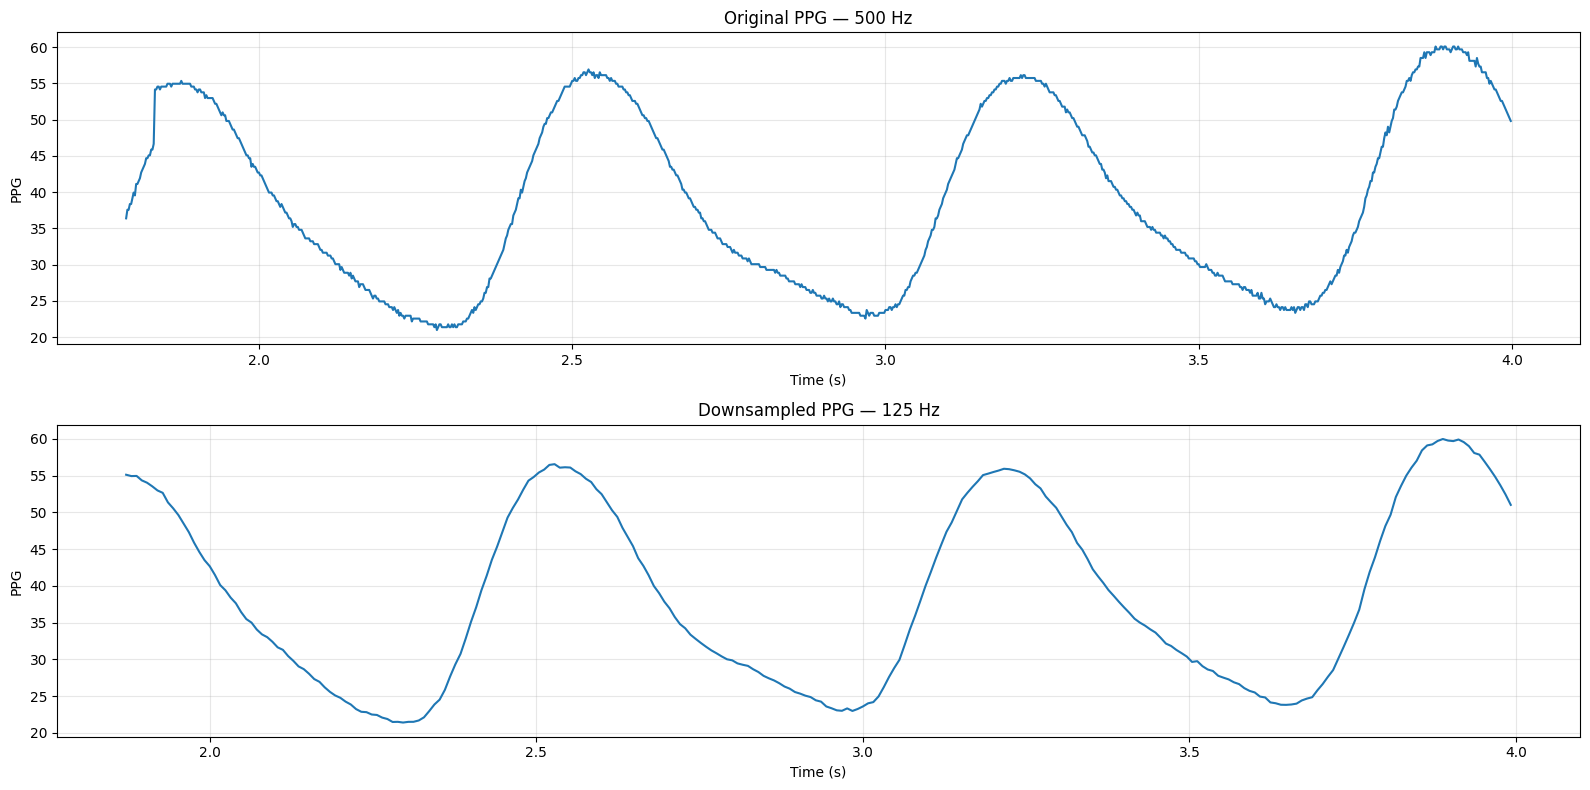

In [15]:
fs_original = 500
fs = 125

time_original = np.arange(len(ppg)) / fs_original
time = np.arange(len(ppg_125)) / fs

plt.figure(figsize=(16, 8))

# -----------------------------------------
# Original PPG
# -----------------------------------------
plt.subplot(2, 1, 1)

plt.plot(
    time_original[:2000],
    ppg[:2000]
)

plt.xlabel("Time (s)")
plt.ylabel("PPG")
plt.title("Original PPG — 500 Hz")
plt.grid(alpha=0.3)


# -----------------------------------------
# Downsampled PPG
# -----------------------------------------
plt.subplot(2, 1, 2)

plt.plot(
    time[:500],
    ppg_125[:500]
)

plt.xlabel("Time (s)")
plt.ylabel("PPG")
plt.title("Downsampled PPG — 125 Hz")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
valid_common_cases = []

invalid_cases = []

for case_id in tqdm(common_cases):

    valid, reason = validate_vitaldb_case(case_id)

    if valid:

        valid_common_cases.append(case_id)

    else:

        invalid_cases.append({
            "case_id": case_id,
            "reason": reason
        })

  0%|          | 0/3238 [00:00<?, ?it/s]


NameError: name 'validate_vitaldb_case' is not defined